# Amazon Sales Analysis

## Project Overview

This project analyzes Amazon sales data to understand sales performance, 
customer behavior, product performance, order trends, and geographic sales patterns.

### Objectives
- Analyze overall sales performance
- Identify top-performing products and categories
- Analyze customer and geographic sales
- Understand order status and payment methods
- Analyze monthly and yearly sales trends
- Generate useful business insights

IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

LOAD DATASET

In [5]:
df = pd.read_csv("Amazon.csv")


DATASET UNDERSTANTING

In [6]:
df.shape

(100000, 20)

In [7]:
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [8]:
df.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount',
       'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus',
       'City', 'State', 'Country', 'SellerID'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OrderID        100000 non-null  str    
 1   OrderDate      100000 non-null  str    
 2   CustomerID     100000 non-null  str    
 3   CustomerName   100000 non-null  str    
 4   ProductID      100000 non-null  str    
 5   ProductName    100000 non-null  str    
 6   Category       100000 non-null  str    
 7   Brand          100000 non-null  str    
 8   Quantity       100000 non-null  int64  
 9   UnitPrice      100000 non-null  float64
 10  Discount       100000 non-null  float64
 11  Tax            100000 non-null  float64
 12  ShippingCost   100000 non-null  float64
 13  TotalAmount    100000 non-null  float64
 14  PaymentMethod  100000 non-null  str    
 15  OrderStatus    100000 non-null  str    
 16  City           100000 non-null  str    
 17  State          100000 non-null  str    
 

In [10]:
df.describe()

,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
std,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332
min,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000


DATA CLEANING

MISSING VALUES CHECK

In [11]:
df.isnull().sum()

OrderID          0
OrderDate        0
CustomerID       0
CustomerName     0
ProductID        0
ProductName      0
Category         0
Brand            0
Quantity         0
UnitPrice        0
Discount         0
Tax              0
ShippingCost     0
TotalAmount      0
PaymentMethod    0
OrderStatus      0
City             0
State            0
Country          0
SellerID         0
dtype: int64

DUPLICATE ROW CHECK

In [12]:
df.duplicated().sum()

np.int64(0)

DUPLICATE ORDERID CHECK

In [13]:
df["OrderID"].duplicated().sum()

np.int64(0)

DUPLICATE CUSTOMER ID CHECK

In [14]:
df["CustomerID"].duplicated().sum()

np.int64(56767)

DATA TYPE CHECK

In [15]:
df.dtypes

OrderID              str
OrderDate            str
CustomerID           str
CustomerName         str
ProductID            str
ProductName          str
Category             str
Brand                str
Quantity           int64
UnitPrice        float64
Discount         float64
Tax              float64
ShippingCost     float64
TotalAmount      float64
PaymentMethod        str
OrderStatus          str
City                 str
State                str
Country              str
SellerID             str
dtype: object

CONVERT ORDERDATE TO DATETIME

In [16]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])
df["OrderDate"].dtype

dtype('<M8[us]')

CHECK INVALID SALES VALUES

In [17]:
df[df["TotalAmount"]<=0]

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID


CHECK INVALID QUANTITY

In [18]:
df[df["Quantity"]<=0]

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID


CHECK UNIQUE VALUES

In [19]:
df.nunique()

OrderID          100000
OrderDate          1825
CustomerID        43233
CustomerName        200
ProductID            50
ProductName          50
Category              6
Brand                10
Quantity              5
UnitPrice         48433
Discount              7
Tax               23002
ShippingCost       1501
TotalAmount       79208
PaymentMethod         6
OrderStatus           5
City                 20
State                13
Country               5
SellerID           1999
dtype: int64

CHECK CATEGORY VALUES

In [20]:
df["Category"].unique()

<StringArray>
[            'Books',    'Home & Kitchen',          'Clothing',
      'Toys & Games', 'Sports & Outdoors',       'Electronics']
Length: 6, dtype: str

CHECK ORDER STATUS VALUES

In [21]:
df["OrderStatus"].unique()

<StringArray>
['Delivered', 'Cancelled', 'Pending', 'Shipped', 'Returned']
Length: 5, dtype: str

DATE AND TIME ANALYSIS PREPARATION

YEAR

In [22]:
df["Year"]=df["OrderDate"].dt.year

MONTH NUMBER

In [23]:
df["Month_Number"] = df["OrderDate"].dt.month

MONTH NAME

In [24]:
df["Month_Name"]= df["OrderDate"].dt.month_name()

QUARTER

In [25]:
df["Quarter"] = df["OrderDate"].dt.quarter

DAY NAME

In [26]:
df["Day_Name"] = df["OrderDate"].dt.day_name()

YEAR-MONTH

In [27]:
df["Year_Month"] = df["OrderDate"].dt.to_period("M").astype(str)

CHECK NEW COLUMNS

In [28]:
df[["OrderDate", "Year", "Month_Number", "Month_Name", "Quarter", "Day_Name", "Year_Month"]].head()

,OrderDate,Year,Month_Number,Month_Name,Quarter,Day_Name,Year_Month
0,2023-01-31,2023,1,January,1,Tuesday,2023-01
1,2023-12-30,2023,12,December,4,Saturday,2023-12
2,2022-05-10,2022,5,May,2,Tuesday,2022-05
3,2023-07-18,2023,7,July,3,Tuesday,2023-07
4,2023-02-04,2023,2,February,1,Saturday,2023-02


CHECK UPDTAED COLUMNS

In [29]:
df.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount',
       'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus',
       'City', 'State', 'Country', 'SellerID', 'Year', 'Month_Number',
       'Month_Name', 'Quarter', 'Day_Name', 'Year_Month'],
      dtype='str')

TOTAL SALES

In [30]:
total_sales = df["TotalAmount"].sum()
print(total_sales)


91825647.92


TOTAL ORDERS

In [31]:
total_orders = df["OrderID"].nunique()
print(total_orders)

100000


TOTAL CUSTOMERS

In [32]:
total_customers = df["CustomerName"].nunique()
print(total_customers)

200


TOTAL QUANTITY SOLD

In [33]:
total_quantity = df["Quantity"].sum()
print(total_quantity)

300140


AVERAGE ORDER VALUE

In [34]:
average_order_value = df["TotalAmount"].mean()
print(average_order_value)

918.2564792000001


KPI SUMMERY

In [35]:
kpi_summery ={"Total Sales":total_sales,"Total Orders":total_orders,"Total Customers":total_customers,
              "Total Quantity Sold":total_quantity,"Average Order Value":average_order_value}
print(kpi_summery)

{'Total Sales': np.float64(91825647.92), 'Total Orders': 100000, 'Total Customers': 200, 'Total Quantity Sold': np.int64(300140), 'Average Order Value': np.float64(918.2564792000001)}


CATEGRTY ANALYSIS

CATEGORY WISE TOTAL SALES

In [36]:
category_sales = (df.groupby("Category")["TotalAmount"].sum().sort_values(ascending=False))
print(category_sales)

Category
Electronics          15584217.18
Sports & Outdoors    15345571.88
Books                15261837.01
Clothing             15253397.50
Toys & Games         15216684.99
Home & Kitchen       15163939.36
Name: TotalAmount, dtype: float64


CATEGORY WISE TOTAL QUANTITY

In [37]:
category_quantity = (df.groupby("Category")["Quantity"].sum().sort_values(ascending=False))
print(category_quantity)

Category
Electronics          50696
Sports & Outdoors    50543
Books                49981
Toys & Games         49773
Home & Kitchen       49624
Clothing             49523
Name: Quantity, dtype: int64


CATEGORY WISE NUMBER OF ORDERS

In [38]:
category_orders = (df.groupby("Category")["OrderID"].nunique().sort_values(ascending=False))
print(category_quantity)

Category
Electronics          50696
Sports & Outdoors    50543
Books                49981
Toys & Games         49773
Home & Kitchen       49624
Clothing             49523
Name: Quantity, dtype: int64


CATEGORY WISE AVERAGE SALES

In [39]:
category_avg_sales = (df.groupby("Category")["TotalAmount"].mean().sort_values(ascending=False))
print(category_avg_sales)

Category
Clothing             927.878673
Electronics          924.714720
Toys & Games         919.881815
Sports & Outdoors    913.209467
Home & Kitchen       912.940359
Books                911.045667
Name: TotalAmount, dtype: float64


CATEGORY SALES PERCENTAGE

In [40]:
category_sales_percentage = (category_sales/category_sales.sum()*100)
print(category_sales_percentage)

Category
Electronics          16.971530
Sports & Outdoors    16.711640
Books                16.620451
Clothing             16.611260
Toys & Games         16.571280
Home & Kitchen       16.513839
Name: TotalAmount, dtype: float64


CATEGORY SUMMERY TABLE


In [41]:
category_summery = pd.DataFrame({"Total Sales":category_sales,"Total Quantity":category_quantity,"Total Orders":category_orders,"Average Sales":category_avg_sales,"Sales Contribution Percentage%":category_sales_percentage})
print(category_summery)

                   Total Sales  Total Quantity  Total Orders  Average Sales  \
Category                                                                      
Books              15261837.01           49981         16752     911.045667   
Clothing           15253397.50           49523         16439     927.878673   
Electronics        15584217.18           50696         16853     924.714720   
Home & Kitchen     15163939.36           49624         16610     912.940359   
Sports & Outdoors  15345571.88           50543         16804     913.209467   
Toys & Games       15216684.99           49773         16542     919.881815   

                   Sales Contribution Percentage%  
Category                                           
Books                                   16.620451  
Clothing                                16.611260  
Electronics                             16.971530  
Home & Kitchen                          16.513839  
Sports & Outdoors                       16.711640  
Toy

CATEGORY SALES CHART

<function matplotlib.pyplot.show(close=None, block=None)>

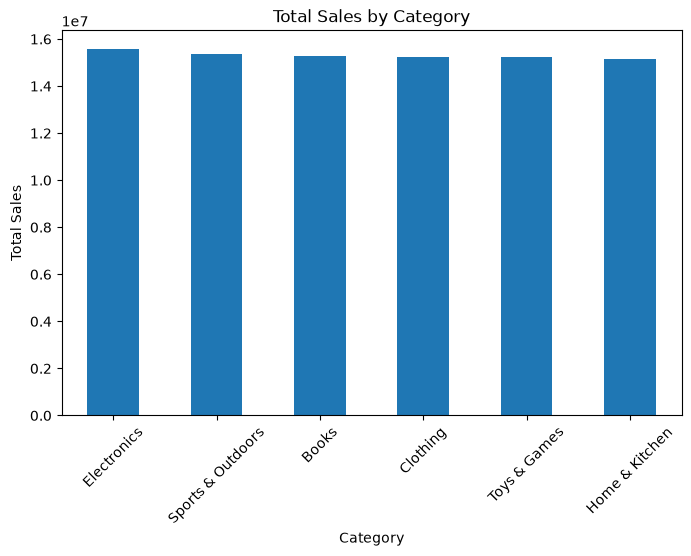

In [42]:
plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout
plt.show

CATEGORY QUANTITY CHART

<function matplotlib.pyplot.show(close=None, block=None)>

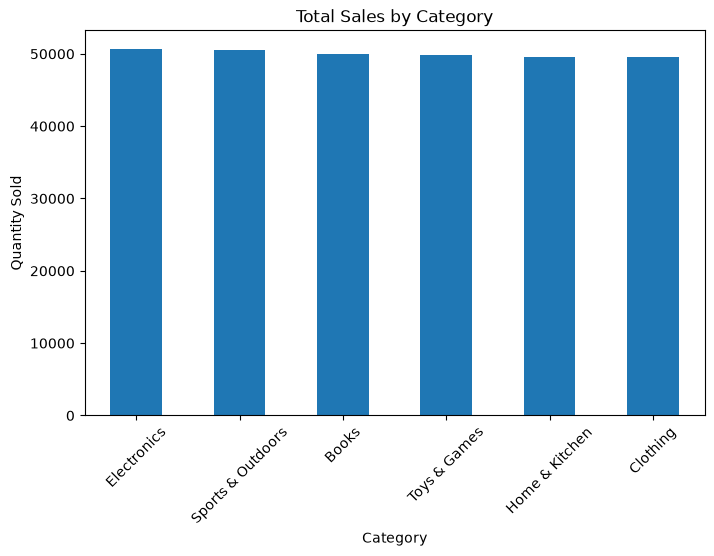

In [ ]:
plt.figure(figsize=(8,5))
category_quantity.plot(kind="bar")
plt.title("Total Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout
plt.show

PRODUCT ANALYSIS

PRODUCTS WISE TOTAL SALES

In [44]:
products_sales=(df.groupby("ProductName")["TotalAmount"].sum().sort_values(ascending=False))
print(products_sales)

ProductName
Memory Card 128GB              1935138.40
LED Desk Lamp                  1921948.41
Mechanical Keyboard            1906963.54
Electric Kettle                1905751.79
Smartwatch                     1901275.59
Dress Shirt                    1896765.36
Water Bottle                   1895467.95
Gaming Mouse                   1895103.98
Kids Toy Car                   1891082.43
Jeans                          1882591.82
Noise Cancelling Headphones    1881108.57
Cookware Set                   1877038.73
Smartphone Case                1875421.41
Microphone                     1871740.68
Smart Light Bulb               1868940.58
4K Monitor                     1866774.35
Phone Tripod                   1866256.31
Board Game                     1863310.96
Vacuum Cleaner                 1855117.83
Router                         1850756.20
Laptop Sleeve                  1848297.80
Yoga Mat                       1847898.09
HDMI Cable 2m                  1847856.25
Desk Organizer        

PRODUCTS WISE QUANTITY SOLD

In [45]:
products_quantity=(df.groupby("ProductName")["Quantity"].sum().sort_values(ascending=False))
print(products_quantity)

ProductName
LED Desk Lamp                  6344
Water Bottle                   6275
Memory Card 128GB              6240
Router                         6202
Board Game                     6200
Microphone                     6196
Gaming Mouse                   6170
Electric Kettle                6165
Mechanical Keyboard            6161
Vacuum Cleaner                 6139
Smart Light Bulb               6131
Kids Toy Car                   6131
Cookware Set                   6130
4K Monitor                     6111
Action Camera                  6104
Noise Cancelling Headphones    6091
Desk Organizer                 6079
Wireless Charger               6079
Yoga Mat                       6077
Smartphone Case                6060
Jeans                          6037
Instant Pot                    6016
Wireless Earbuds               6008
Webcam Full HD                 6002
Office Chair                   5998
Portable SSD 1TB               5996
Laptop Sleeve                  5992
HDMI Cable 2m   

PRODUCTS WISE NUMBER OF ORDERS

In [46]:
products_orders=(df.groupby("ProductName")["OrderID"].nunique().sort_values(ascending=False))
print(products_orders)

ProductName
LED Desk Lamp                  2098
Water Bottle                   2088
Cookware Set                   2058
Router                         2054
Electric Kettle                2054
Yoga Mat                       2041
Memory Card 128GB              2039
Board Game                     2039
Smart Light Bulb               2036
Mechanical Keyboard            2034
Microphone                     2034
Wireless Charger               2034
Noise Cancelling Headphones    2031
Portable SSD 1TB               2030
Desk Organizer                 2026
Drone Mini                     2026
Action Camera                  2024
Office Chair                   2018
Vacuum Cleaner                 2017
Instant Pot                    2016
Webcam Full HD                 2013
Gaming Mouse                   2010
Wireless Earbuds               2008
Air Fryer                      2007
Dress Shirt                    2007
4K Monitor                     2006
Kids Toy Car                   2004
Running Shoes   

TOP 10 PRODUCT BY SALES

In [47]:
top10_products_by_sales = products_sales.head(10)
print(top10_products_by_sales)

ProductName
Memory Card 128GB      1935138.40
LED Desk Lamp          1921948.41
Mechanical Keyboard    1906963.54
Electric Kettle        1905751.79
Smartwatch             1901275.59
Dress Shirt            1896765.36
Water Bottle           1895467.95
Gaming Mouse           1895103.98
Kids Toy Car           1891082.43
Jeans                  1882591.82
Name: TotalAmount, dtype: float64


TOP 10 PRODUCT BY QUANTITY

In [48]:
top10_products_by_quantity = products_quantity.head(10)
print(top10_products_by_quantity)

ProductName
LED Desk Lamp          6344
Water Bottle           6275
Memory Card 128GB      6240
Router                 6202
Board Game             6200
Microphone             6196
Gaming Mouse           6170
Electric Kettle        6165
Mechanical Keyboard    6161
Vacuum Cleaner         6139
Name: Quantity, dtype: int64


TOP 10 PRODUCTS BY ORDERS

In [49]:
top10_products_by_orders = products_orders.head(10)
print(top10_products_by_orders)

ProductName
LED Desk Lamp          2098
Water Bottle           2088
Cookware Set           2058
Router                 2054
Electric Kettle        2054
Yoga Mat               2041
Memory Card 128GB      2039
Board Game             2039
Smart Light Bulb       2036
Mechanical Keyboard    2034
Name: OrderID, dtype: int64


PRODUTS SUMMERY TABLES

In [50]:
products_summery =pd.DataFrame({"Total Sales":products_sales,"Total Quantity":products_quantity,"Total Orders":products_orders})
print(products_summery)

                             Total Sales  Total Quantity  Total Orders
ProductName                                                           
4K Monitor                    1866774.35            6111          2006
Action Camera                 1829029.24            6104          2024
Air Fryer                     1789927.34            5956          2007
Backpack                      1749971.14            5848          1910
Bluetooth Speaker             1803356.76            5782          1913
Board Game                    1863310.96            6200          2039
Car Charger                   1779795.27            5754          1917
Children's Book               1738112.57            5619          1914
Cookware Set                  1877038.73            6130          2058
Desk Organizer                1843103.26            6079          2026
Desk Plant                    1759672.62            5847          1941
Dress Shirt                   1896765.36            5960          2007
Drone 

TOP 10 PRODUCTS SALES CHART

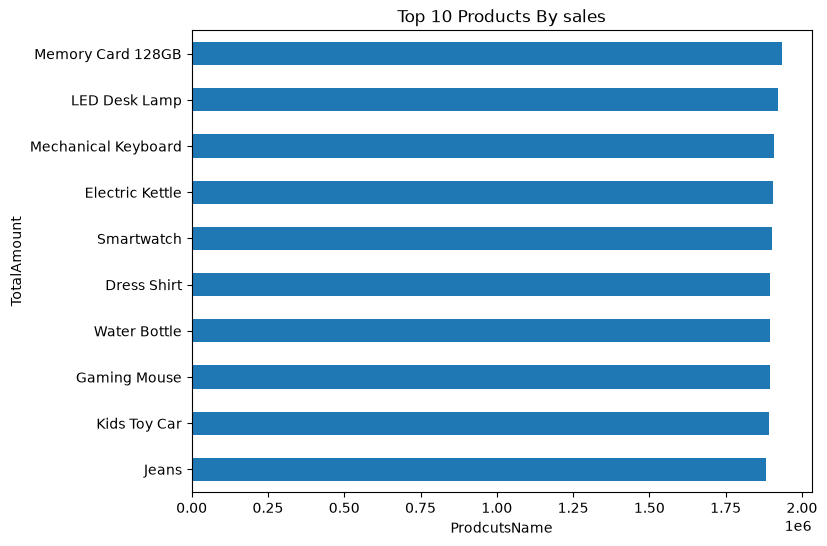

In [51]:
plt.figure(figsize=(8,6))
top10_products_by_sales.sort_values().plot(kind="barh")
plt.title("Top 10 Products By sales")
plt.xlabel("ProdcutsName")
plt.ylabel("TotalAmount")
plt.tight_layout
plt.show()

TOP 10 PRODUCTS QUANTITY CHART

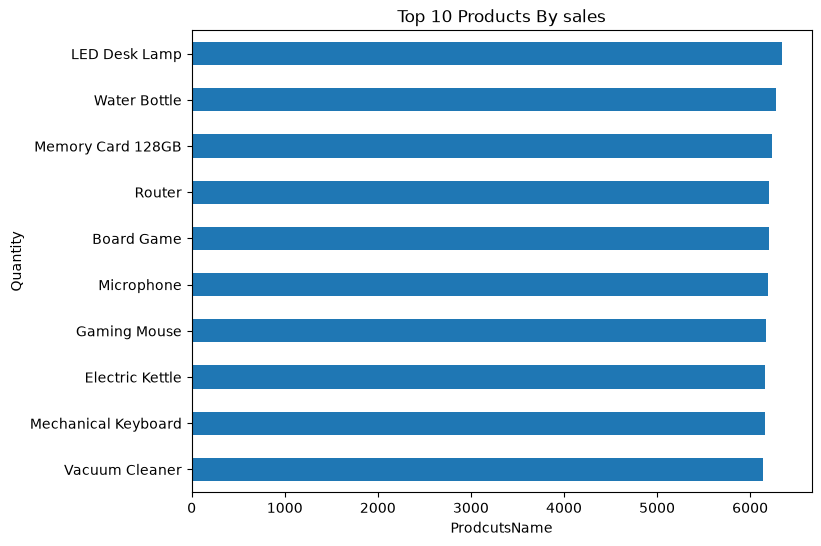

In [ ]:
plt.figure(figsize=(8,6))
top10_products_by_quantity.sort_values().plot(kind="barh")
plt.title("Top 10 Products By Quantity Sold")
plt.xlabel("ProdcutsName")
plt.ylabel("Quantity")
plt.tight_layout
plt.show()

BRAND ANALYSIS

BRAND WISE TOTAL SALES

In [53]:
brand_sales =(df.groupby("Brand")["TotalAmount"].sum().sort_values(ascending=False))
print(brand_sales)

Brand
CoreTech      9343720.59
KiddoFun      9324749.55
ReadMore      9278406.63
UrbanStyle    9249027.45
Zenith        9239960.39
Apex          9147604.72
NexPro        9078824.97
FitLife       9061444.68
BrightLux     9056816.11
HomeEase      9045092.83
Name: TotalAmount, dtype: float64


BRAND WISE TOTAL SOLD QUANTITY

In [54]:
brand_quantity =(df.groupby("Brand")["Quantity"].sum().sort_values(ascending=False))
print(brand_quantity)

Brand
CoreTech      30430
ReadMore      30421
KiddoFun      30168
FitLife       30121
UrbanStyle    30104
Zenith        30058
Apex          29955
NexPro        29791
BrightLux     29616
HomeEase      29476
Name: Quantity, dtype: int64


BRAND WISE TOTAL ORDERS

In [55]:
brand_orders =(df.groupby("Brand")["OrderID"].nunique().sort_values(ascending=False))
print(brand_orders)

Brand
ReadMore      10204
FitLife       10147
CoreTech      10127
KiddoFun      10077
Zenith         9990
NexPro         9962
Apex           9937
BrightLux      9907
UrbanStyle     9854
HomeEase       9795
Name: OrderID, dtype: int64


TOP 10 BRAND BY SALES

In [56]:
top10_brands_by_sales = brand_sales.head(10)
print(top10_brands_by_sales)

Brand
CoreTech      9343720.59
KiddoFun      9324749.55
ReadMore      9278406.63
UrbanStyle    9249027.45
Zenith        9239960.39
Apex          9147604.72
NexPro        9078824.97
FitLife       9061444.68
BrightLux     9056816.11
HomeEase      9045092.83
Name: TotalAmount, dtype: float64


BRAND SUMMERY TABLE

In [57]:
brand_summery=pd.DataFrame({"Total Sales":brand_sales,"Total Quantity":brand_quantity,"Total Orders":brand_orders})
print(brand_summery)

            Total Sales  Total Quantity  Total Orders
Brand                                                
Apex         9147604.72           29955          9937
BrightLux    9056816.11           29616          9907
CoreTech     9343720.59           30430         10127
FitLife      9061444.68           30121         10147
HomeEase     9045092.83           29476          9795
KiddoFun     9324749.55           30168         10077
NexPro       9078824.97           29791          9962
ReadMore     9278406.63           30421         10204
UrbanStyle   9249027.45           30104          9854
Zenith       9239960.39           30058          9990


TOP 10 BRANDS SALES CHART

<function matplotlib.pyplot.show(close=None, block=None)>

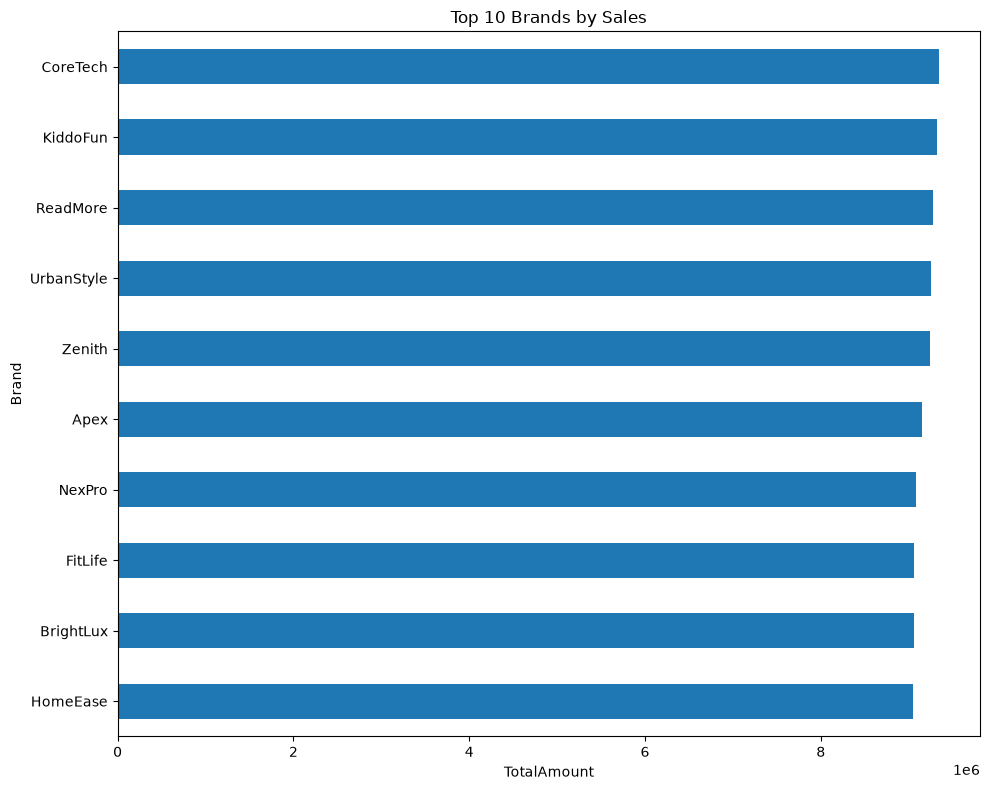

In [58]:
plt.figure(figsize=(10,8))
top10_brands_by_sales.sort_values().plot(kind="barh")
plt.title("Top 10 Brands by Sales")
plt.xlabel("TotalAmount")
plt.ylabel("Brand")
plt.tight_layout()
plt.show


TOP 10 BRANDS QUANTITY CHART

<function matplotlib.pyplot.show(close=None, block=None)>

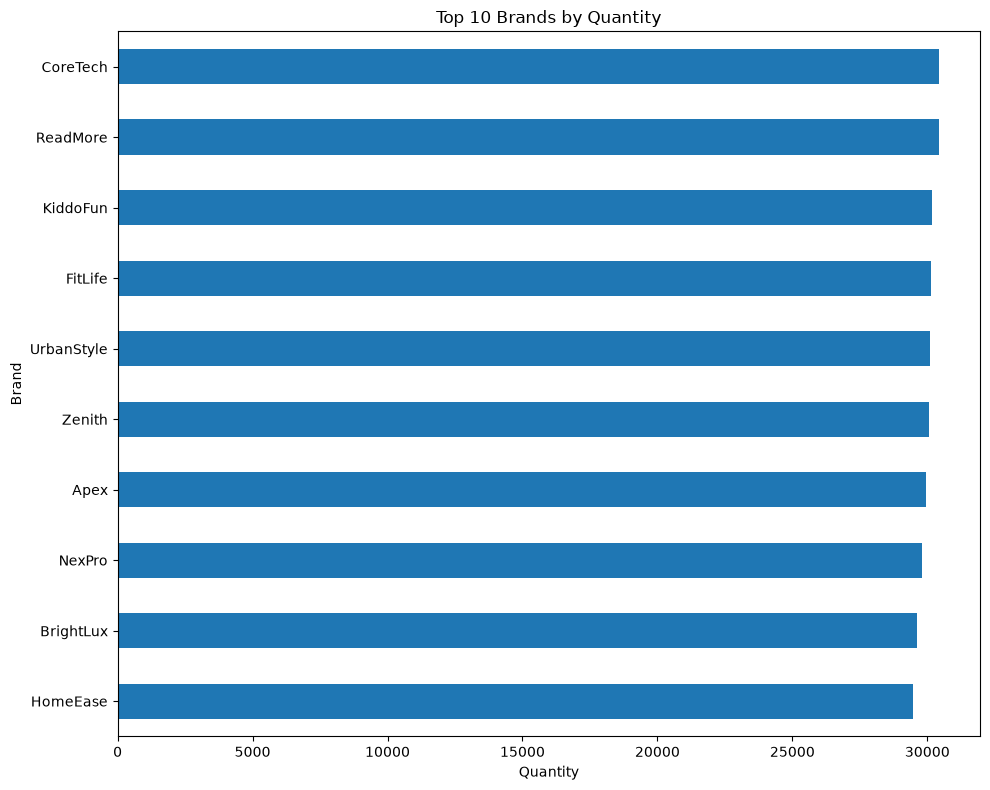

In [59]:
top10_brands_by_quantity=brand_quantity.head(10)
plt.figure(figsize=(10,8))
top10_brands_by_quantity.sort_values().plot(kind="barh")
plt.title("Top 10 Brands by Quantity")
plt.xlabel("Quantity")
plt.ylabel("Brand")
plt.tight_layout()
plt.show


CUSTOMER ANALYSIS

CUSTOMER WISE TOTAL SALES

In [60]:
customer_sales = (df.groupby("CustomerName")["TotalAmount"].sum().sort_values(ascending=False))
print(customer_sales)

CustomerName
Pooja Kapoor    547832.64
Vihaan Singh    526675.89
Pooja Singh     516451.45
Kabir Joshi     515361.68
Aditya Gupta    515005.09
                  ...    
Sunita Reddy    403238.35
Kabir Reddy     399224.49
Ritika Mehta    391922.47
Vikas Gupta     389299.02
Rohit Joshi     376778.76
Name: TotalAmount, Length: 200, dtype: float64


CUSTOMER WISE NUMBER OF ORDERS

In [61]:
customer_orders = (df.groupby("CustomerName")["OrderID"].nunique().sort_values(ascending=False))
print(customer_orders)

CustomerName
Karan Joshi     556
Arjun Kumar     553
Pooja Kapoor    552
Rohit Gupta     547
Vihaan Singh    544
               ... 
Kabir Patel     454
Aman Sharma     453
Sneha Singh     450
Sunita Reddy    440
Vikas Gupta     436
Name: OrderID, Length: 200, dtype: int64


CUSTOMER WISE TOTAL QUANTITY

In [62]:
customer_quantity = (df.groupby("CustomerName")["Quantity"].sum().sort_values(ascending=False))
print(customer_quantity)

CustomerName
Vihaan Singh    1705
Pooja Kapoor    1696
Vihaan Mehta    1665
Neha Patel      1653
Neha Mehta      1647
                ... 
Ritika Joshi    1358
Anjali Joshi    1353
Sunita Reddy    1342
Rohit Joshi     1332
Vikas Gupta     1305
Name: Quantity, Length: 200, dtype: int64


AVERGAE SPENDING PER CUSTOMER

In [63]:
customer_average_spending = (customer_sales/customer_orders)
customer_average_spending.head(10)
print(customer_average_spending)

CustomerName
Aarav Gupta      950.060185
Aarav Joshi      900.807094
Aarav Kapoor     898.635340
Aarav Kumar      986.392495
Aarav Mehta      920.529817
                    ...    
Vivaan Patel     983.167296
Vivaan Reddy     939.712089
Vivaan Sharma    930.676379
Vivaan Singh     876.263499
Vivaan Verma     904.978263
Length: 200, dtype: float64


TOP 10 CUSTOMER BY SALES

In [64]:
top10_customer_by_sales =customer_sales.head(10)
print(top10_customer_by_sales)

CustomerName
Pooja Kapoor    547832.64
Vihaan Singh    526675.89
Pooja Singh     516451.45
Kabir Joshi     515361.68
Aditya Gupta    515005.09
Mohit Singh     513513.19
Sunita Mehta    511642.91
Aman Reddy      511236.91
Karan Singh     510900.60
Simran Singh    509337.35
Name: TotalAmount, dtype: float64


CUSTOMER SUMMERY TABLE

In [65]:
customer_summery=pd.DataFrame({"Total Sales":customer_sales,"Total Order":customer_orders,"Total Quantity":customer_quantity,"Average Spending":customer_average_spending})
customer_summery.head(10)
print(customer_summery)

               Total Sales  Total Order  Total Quantity  Average Spending
CustomerName                                                             
Aarav Gupta      462679.31          487            1457        950.060185
Aarav Joshi      449502.74          499            1484        900.807094
Aarav Kapoor     449317.67          500            1527        898.635340
Aarav Kumar      450781.37          457            1439        986.392495
Aarav Mehta      451980.14          491            1486        920.529817
...                    ...          ...             ...               ...
Vivaan Patel     458155.96          466            1483        983.167296
Vivaan Reddy     463278.06          493            1499        939.712089
Vivaan Sharma    485813.07          522            1566        930.676379
Vivaan Singh     405710.00          463            1361        876.263499
Vivaan Verma     453394.11          501            1456        904.978263

[200 rows x 4 columns]


TOP 10 CUSTOMER SALES CHART

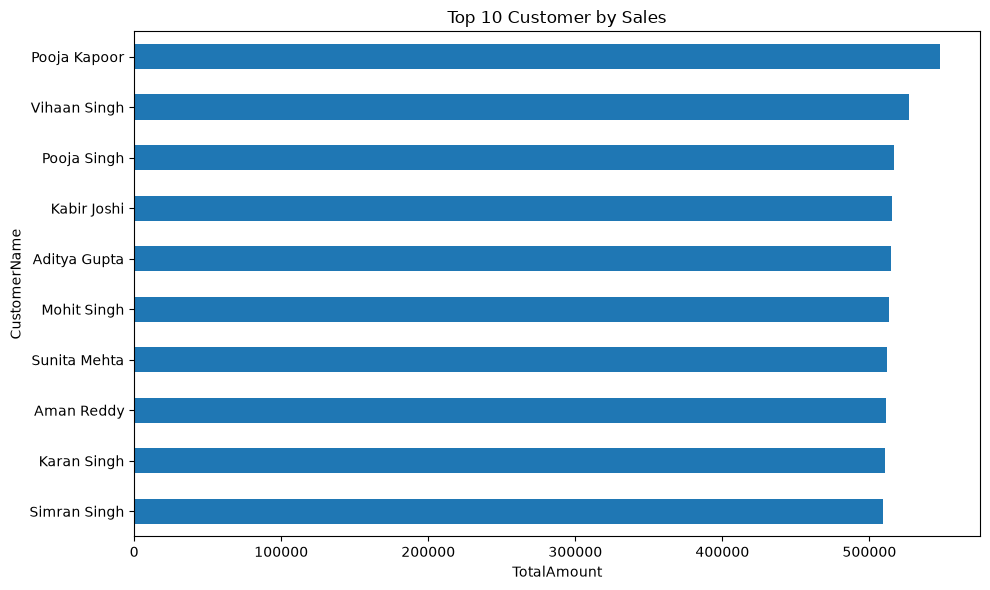

In [66]:
plt.figure(figsize=(10,6))
top10_customer_by_sales.sort_values().plot(kind="barh")
plt.title("Top 10 Customer by Sales")
plt.xlabel("TotalAmount")
plt.ylabel("CustomerName")
plt.tight_layout()
plt.show()

TOP 10 CUSTOMER ORDER CHART

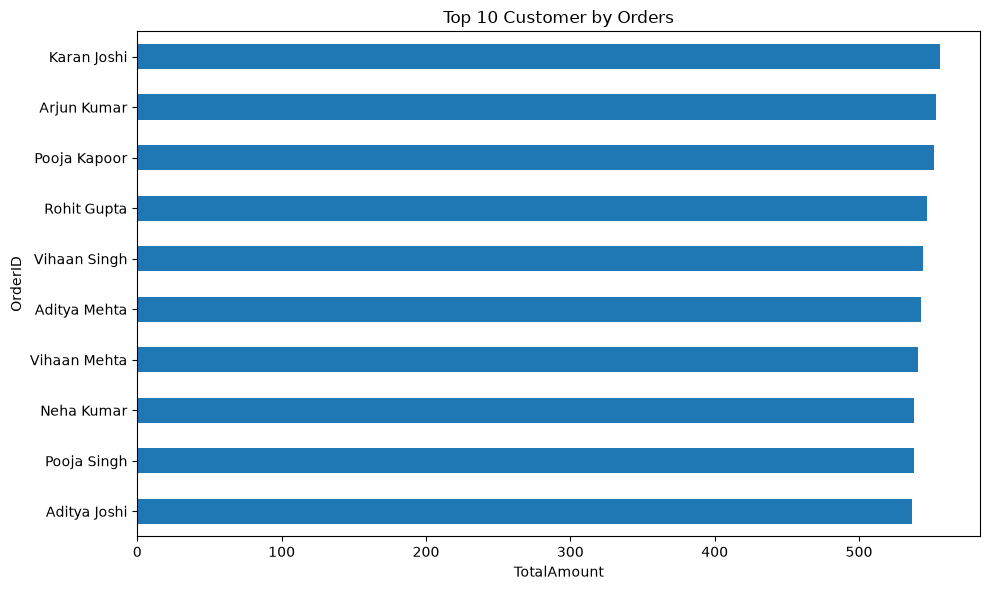

In [67]:
top10_customer_by_orders =customer_orders.head(10)
plt.figure(figsize=(10,6))
top10_customer_by_orders.sort_values().plot(kind="barh")
plt.title("Top 10 Customer by Orders")
plt.xlabel("TotalAmount")
plt.ylabel("OrderID")
plt.tight_layout()
plt.show()

Geographics analysis

COUNTRY WISE SALES

In [68]:
country_sales = (df.groupby("Country")["TotalAmount"].sum().sort_values(ascending=False))
print(country_sales)

Country
United States     64310048.50
India             13875839.12
Canada             5323757.00
United Kingdom     4526896.86
Australia          3789106.44
Name: TotalAmount, dtype: float64


STATE WISE SALES

In [69]:
state_sales = (df.groupby("State")["TotalAmount"].sum().sort_values(ascending=False))
print(state_sales)

State
TX    22862540.54
CA    18231196.79
NC     4747701.73
WA     4660962.17
PA     4650673.88
CO     4638498.97
IL     4632847.44
OH     4615442.32
IN     4609048.43
FL     4597177.27
NY     4554358.08
DC     4520876.11
AZ     4504324.19
Name: TotalAmount, dtype: float64


CITY WISE SALES

In [70]:
city_sales = (df.groupby("City")["TotalAmount"].sum().sort_values(ascending=False))
print(city_sales)

City
Charlotte        4747701.73
Dallas           4730108.67
San Jose         4669614.33
Seattle          4660962.17
Philadelphia     4650673.88
Denver           4638498.97
Austin           4638403.18
Chicago          4632847.44
Los Angeles      4620629.78
Columbus         4615442.32
Indianapolis     4609048.43
Jacksonville     4597177.27
New York         4554358.08
Washington       4520876.11
San Francisco    4512087.61
San Antonio      4506320.97
Phoenix          4504324.19
Fort Worth       4502058.68
Houston          4485649.04
San Diego        4428865.07
Name: TotalAmount, dtype: float64


TOP 10 STATES

In [71]:
top10_states = state_sales.head(10)
print(top10_states)

State
TX    22862540.54
CA    18231196.79
NC     4747701.73
WA     4660962.17
PA     4650673.88
CO     4638498.97
IL     4632847.44
OH     4615442.32
IN     4609048.43
FL     4597177.27
Name: TotalAmount, dtype: float64


TOP 10 CITIES

In [72]:
top10_city = city_sales.head(10)
print(top10_city)

City
Charlotte       4747701.73
Dallas          4730108.67
San Jose        4669614.33
Seattle         4660962.17
Philadelphia    4650673.88
Denver          4638498.97
Austin          4638403.18
Chicago         4632847.44
Los Angeles     4620629.78
Columbus        4615442.32
Name: TotalAmount, dtype: float64


GEOGRAPHIC SUMMERY

In [73]:
geographic_analysis = pd.DataFrame({"State Sales":state_sales,"City Sales":city_sales})
geographic_analysis.head(10)
print(geographic_analysis)

               State Sales  City Sales
AZ              4504324.19         NaN
Austin                 NaN  4638403.18
CA             18231196.79         NaN
CO              4638498.97         NaN
Charlotte              NaN  4747701.73
Chicago                NaN  4632847.44
Columbus               NaN  4615442.32
DC              4520876.11         NaN
Dallas                 NaN  4730108.67
Denver                 NaN  4638498.97
FL              4597177.27         NaN
Fort Worth             NaN  4502058.68
Houston                NaN  4485649.04
IL              4632847.44         NaN
IN              4609048.43         NaN
Indianapolis           NaN  4609048.43
Jacksonville           NaN  4597177.27
Los Angeles            NaN  4620629.78
NC              4747701.73         NaN
NY              4554358.08         NaN
New York               NaN  4554358.08
OH              4615442.32         NaN
PA              4650673.88         NaN
Philadelphia           NaN  4650673.88
Phoenix                Na

TOP 10 STATE CHART

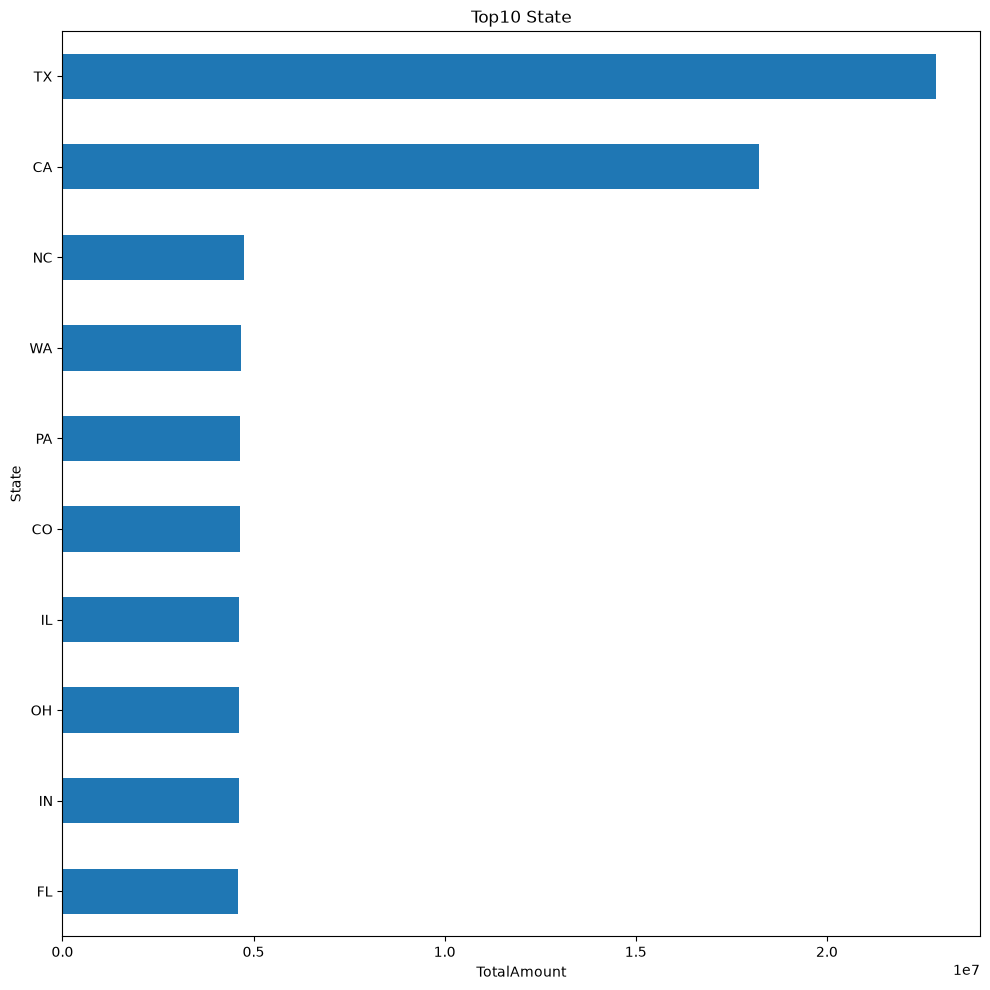

In [74]:
plt.figure(figsize=(10,10))
top10_states.sort_values().plot(kind="barh")
plt.title("Top10 State")
plt.xlabel("TotalAmount")
plt.ylabel("State")
plt.tight_layout()
plt.show()

TOP 10 CITY CHART

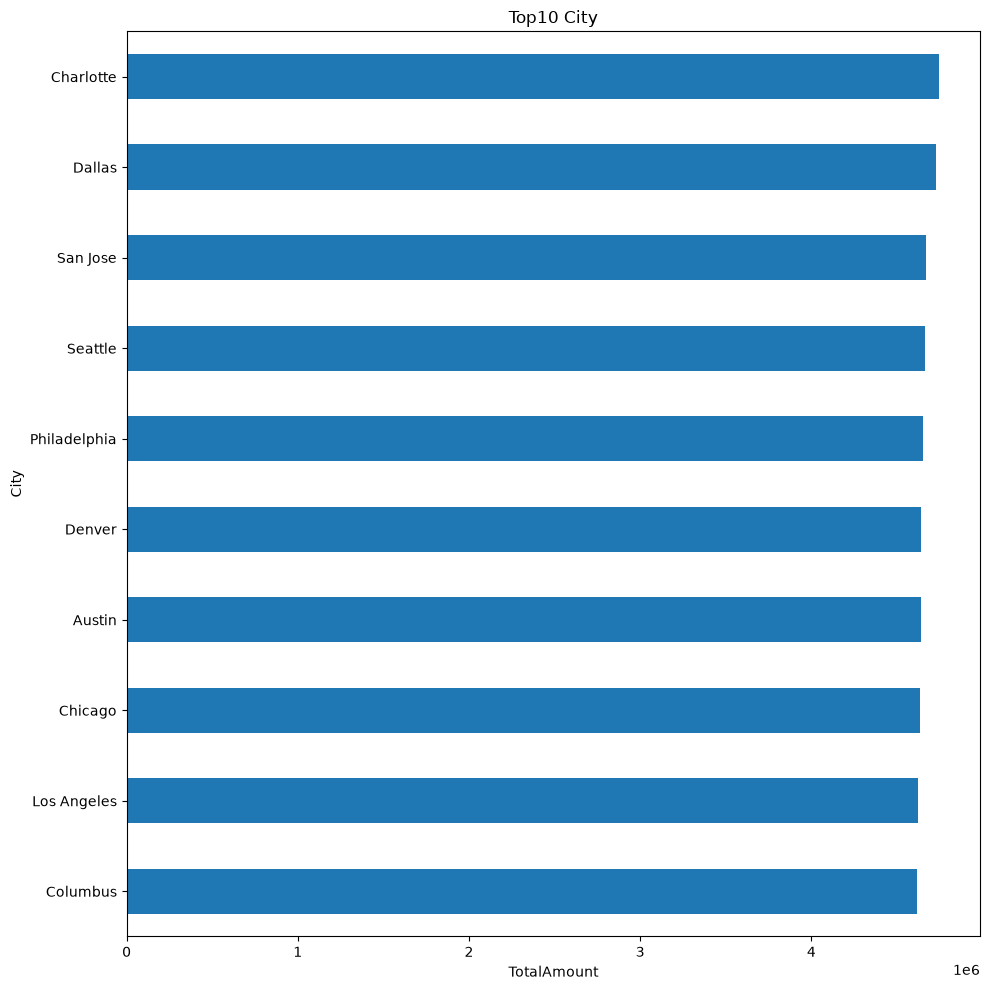

In [75]:
plt.figure(figsize=(10,10))
top10_city.sort_values().plot(kind="barh")
plt.title("Top10 City")
plt.xlabel("TotalAmount")
plt.ylabel("City")
plt.tight_layout()
plt.show()

ORDER STATUS ANALYSIS

ORDER STATUS COUNT

In [76]:
order_status_count = (df.groupby("OrderStatus")["OrderID"].nunique().sort_values(ascending=False))
print(order_status_count)

OrderStatus
Delivered    74628
Shipped      15192
Pending       4103
Returned      3049
Cancelled     3028
Name: OrderID, dtype: int64


ORDER STATUS WISE SALES

In [77]:
order_status_sales = (df.groupby("OrderStatus")["TotalAmount"].sum().sort_values(ascending=False))
print(order_status_sales)

OrderStatus
Delivered    68372677.10
Shipped      14083628.99
Pending       3737556.98
Cancelled     2851122.39
Returned      2780662.46
Name: TotalAmount, dtype: float64


ORDER STATUS WISE QUANTITY

In [78]:
order_status_quantity = (df.groupby("OrderStatus")["Quantity"].sum().sort_values(ascending=False))
print(order_status_quantity)

OrderStatus
Delivered    223759
Shipped       45660
Pending       12338
Cancelled      9242
Returned       9141
Name: Quantity, dtype: int64


ORDER STATUES SUMMERY TABLE

In [79]:
order_status_summery = pd.DataFrame({"Total Orders":order_status_count,"Total Quantity":order_status_quantity,"Total Sales":order_status_sales})
print(order_status_summery)

             Total Orders  Total Quantity  Total Sales
OrderStatus                                           
Cancelled            3028            9242   2851122.39
Delivered           74628          223759  68372677.10
Pending              4103           12338   3737556.98
Returned             3049            9141   2780662.46
Shipped             15192           45660  14083628.99


ORDER STATUS PERCENTAGE

In [80]:
order_status_percentage = (order_status_count/order_status_count.sum()*100)
print(order_status_percentage)

OrderStatus
Delivered    74.628
Shipped      15.192
Pending       4.103
Returned      3.049
Cancelled     3.028
Name: OrderID, dtype: float64


ORDER STATUS -ORDER CHART

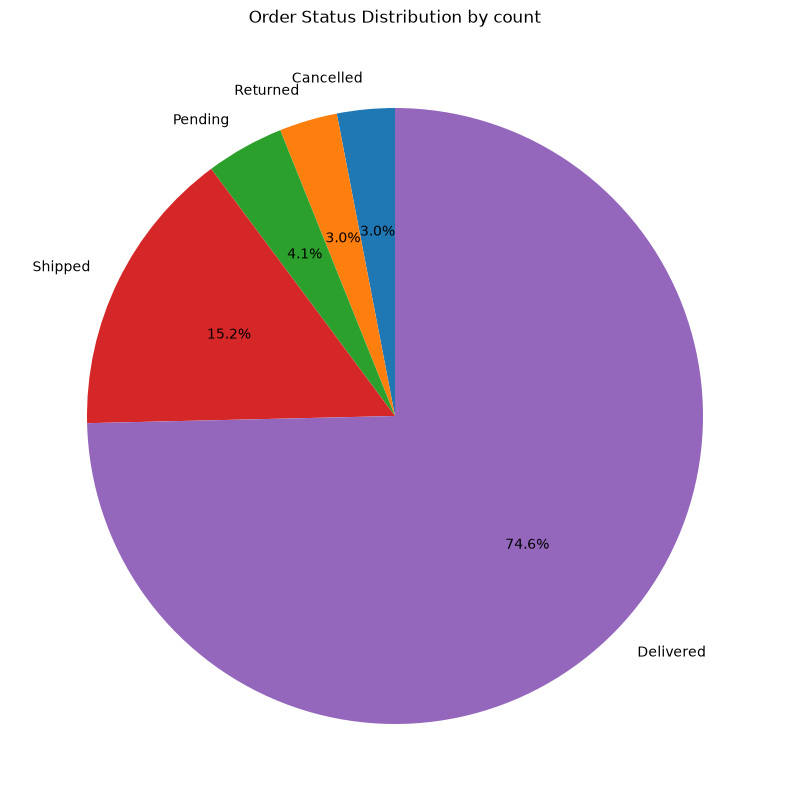

In [81]:
plt.figure(figsize=(10,10))
order_status_count.sort_values().plot(kind="pie",autopct="%1.1f%%",startangle=90)
plt.title("Order Status Distribution by count")
plt.ylabel("")
plt.show()

ORDER STATUS-SALES CHART

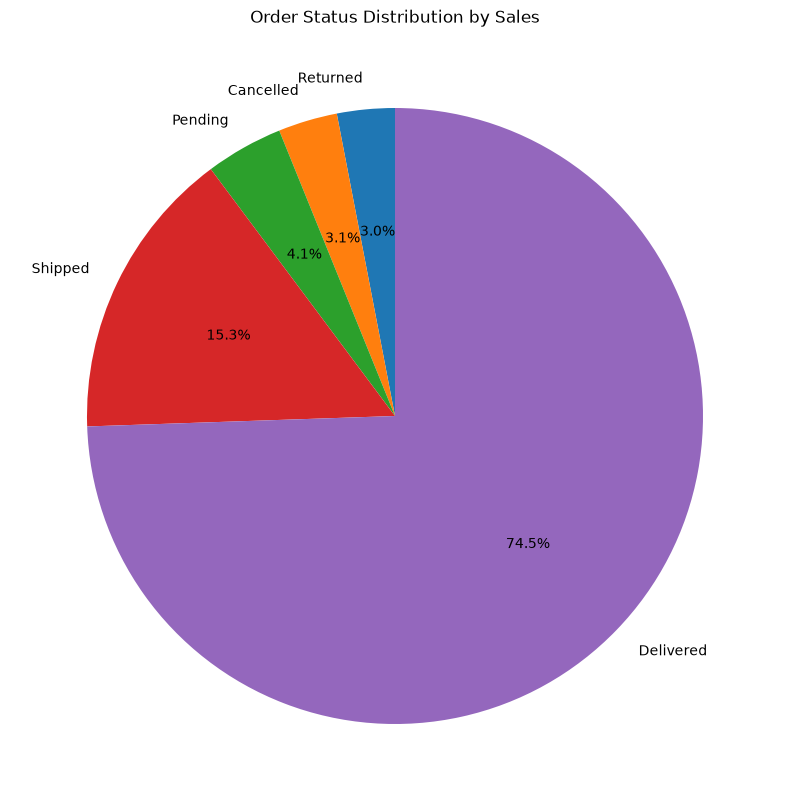

In [82]:
plt.figure(figsize=(10,10))
order_status_sales.sort_values().plot(kind="pie",autopct="%1.1f%%",startangle=90)
plt.title("Order Status Distribution by Sales")
plt.ylabel("")
plt.show()

PAYMENT METHOD ANALYSIS

PAYMENT METHOD WISE ORDER

In [83]:
payment_method_orders =(df.groupby("PaymentMethod")["OrderID"].nunique().sort_values(ascending=False))
print(payment_method_orders)

PaymentMethod
Credit Card         35038
Debit Card          20024
UPI                 15066
Amazon Pay          15017
Net Banking          9927
Cash on Delivery     4928
Name: OrderID, dtype: int64


PAYMENT METHOD WISE SALES

In [84]:
payment_method_sales =(df.groupby("PaymentMethod")["TotalAmount"].sum().sort_values(ascending=False))
print(payment_method_sales)

PaymentMethod
Credit Card         32122158.69
Debit Card          18538678.53
UPI                 13896028.55
Amazon Pay          13697498.42
Net Banking          9055674.57
Cash on Delivery     4515609.16
Name: TotalAmount, dtype: float64


PAYMENT METHOD WISE QUANTITY

In [85]:
payment_method_quantity =(df.groupby("PaymentMethod")["Quantity"].sum().sort_values(ascending=False))
print(payment_method_quantity)

PaymentMethod
Credit Card         105046
Debit Card           60242
UPI                  45218
Amazon Pay           45099
Net Banking          29699
Cash on Delivery     14836
Name: Quantity, dtype: int64


PAYMENT METHOD PERCENTAGE

In [86]:
payment_method_percentage = (payment_method_orders/payment_method_orders.sum()*100)
print(payment_method_percentage)

PaymentMethod
Credit Card         35.038
Debit Card          20.024
UPI                 15.066
Amazon Pay          15.017
Net Banking          9.927
Cash on Delivery     4.928
Name: OrderID, dtype: float64


PAYMENT SUMMERY TABLE

In [87]:
payment_summery = pd.DataFrame({"Total Order":payment_method_orders,"Total Sales":payment_method_sales,"Total Quantity":payment_method_quantity,"Order Share%":payment_method_percentage})
print(payment_summery)

                  Total Order  Total Sales  Total Quantity  Order Share%
PaymentMethod                                                           
Credit Card             35038  32122158.69          105046        35.038
Debit Card              20024  18538678.53           60242        20.024
UPI                     15066  13896028.55           45218        15.066
Amazon Pay              15017  13697498.42           45099        15.017
Net Banking              9927   9055674.57           29699         9.927
Cash on Delivery         4928   4515609.16           14836         4.928


PAYMENT MATHOD- ORDERS PIE CHART

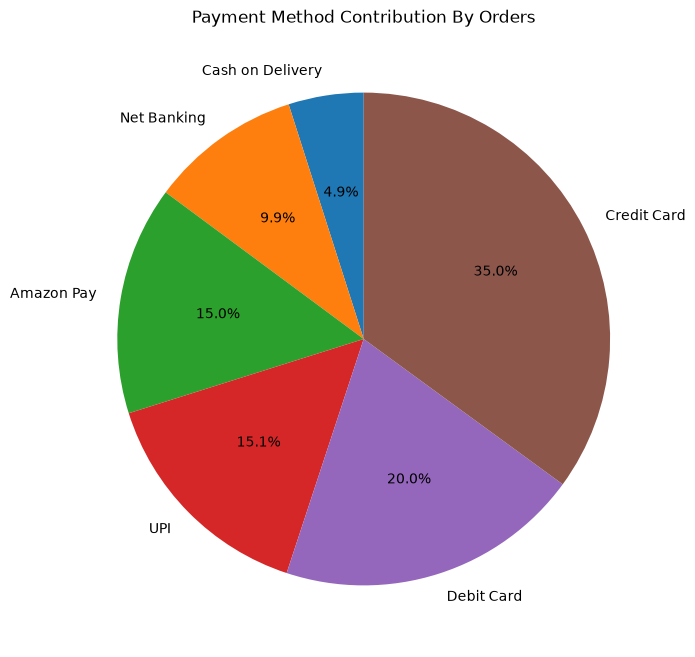

In [88]:
plt.figure(figsize=(8,8))
payment_method_orders.sort_values().plot(kind="pie",autopct="%1.1f%%",startangle=90)
plt.title("Payment Method Contribution By Orders")
plt.ylabel("")
plt.show()

PAYMENT MATHOD- SALES CHART

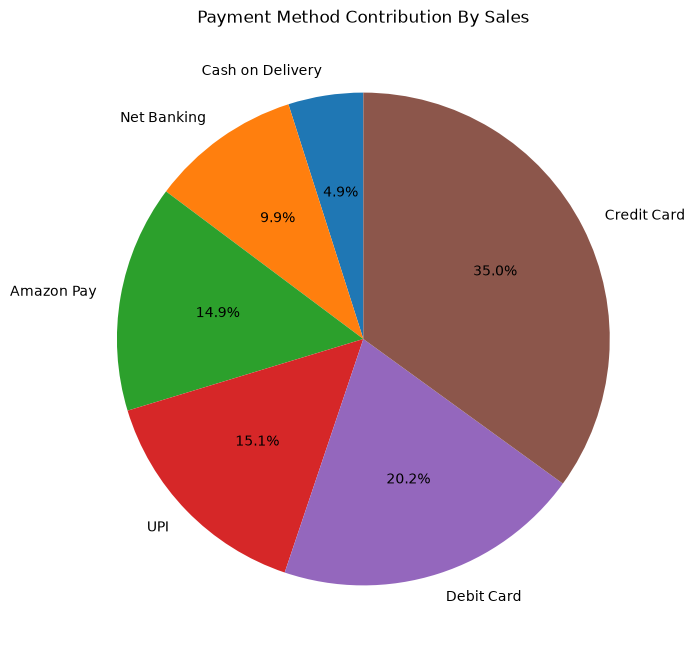

In [89]:
plt.figure(figsize=(8,8))
payment_method_sales.sort_values().plot(kind="pie",autopct="%1.1f%%",startangle=90)
plt.title("Payment Method Contribution By Sales")
plt.ylabel("")
plt.show()

TIME SERIES ANALYSIS

YEAR WISE SALES

In [90]:
yearly_sales =(df.groupby("Year")["TotalAmount"].sum().sort_index())
print(yearly_sales)

Year
2020    18529864.02
2021    18248574.81
2022    18367248.41
2023    18513912.19
2024    18166048.49
Name: TotalAmount, dtype: float64


YEAR WISE ORDERS

In [91]:
yearly_orders =(df.groupby("Year")["OrderID"].nunique().sort_index())
print(yearly_orders)

Year
2020    20066
2021    19890
2022    20078
2023    20096
2024    19870
Name: OrderID, dtype: int64


MONTH WISE SALES

In [92]:
monthly_sales =(df.groupby("Year_Month")["TotalAmount"].sum().sort_index())
print(monthly_sales)

Year_Month
2020-01    1637069.40
2020-02    1339388.21
2020-03    1587125.66
2020-04    1588347.29
2020-05    1533834.17
2020-06    1500269.29
2020-07    1552981.94
2020-08    1640874.93
2020-09    1554682.21
2020-10    1515403.62
2020-11    1502232.24
2020-12    1577655.06
2021-01    1575253.23
2021-02    1425365.99
2021-03    1484165.89
2021-04    1470885.02
2021-05    1571842.25
2021-06    1593398.08
2021-07    1596668.40
2021-08    1545324.30
2021-09    1534912.30
2021-10    1511118.44
2021-11    1419480.77
2021-12    1520160.14
2022-01    1609759.87
2022-02    1369866.29
2022-03    1589809.35
2022-04    1515497.24
2022-05    1527845.26
2022-06    1533829.81
2022-07    1556516.29
2022-08    1541701.50
2022-09    1457859.60
2022-10    1534349.51
2022-11    1525937.46
2022-12    1604276.23
2023-01    1567772.07
2023-02    1384957.09
2023-03    1557146.56
2023-04    1560322.12
2023-05    1588151.65
2023-06    1485367.09
2023-07    1562298.78
2023-08    1585424.79
2023-09    1543306.82

MONTH WISE ORDERS

In [93]:
monthly_orders =(df.groupby("Year_Month")["OrderID"].nunique().sort_index())
print(monthly_orders)

Year_Month
2020-01    1730
2020-02    1490
2020-03    1685
2020-04    1692
2020-05    1672
2020-06    1633
2020-07    1687
2020-08    1783
2020-09    1679
2020-10    1647
2020-11    1639
2020-12    1729
2021-01    1764
2021-02    1516
2021-03    1620
2021-04    1594
2021-05    1716
2021-06    1668
2021-07    1718
2021-08    1704
2021-09    1674
2021-10    1672
2021-11    1587
2021-12    1657
2022-01    1744
2022-02    1510
2022-03    1710
2022-04    1636
2022-05    1709
2022-06    1690
2022-07    1689
2022-08    1717
2022-09    1645
2022-10    1633
2022-11    1642
2022-12    1753
2023-01    1721
2023-02    1540
2023-03    1683
2023-04    1641
2023-05    1709
2023-06    1650
2023-07    1712
2023-08    1733
2023-09    1665
2023-10    1660
2023-11    1656
2023-12    1726
2024-01    1679
2024-02    1562
2024-03    1740
2024-04    1647
2024-05    1753
2024-06    1671
2024-07    1631
2024-08    1731
2024-09    1613
2024-10    1642
2024-11    1624
2024-12    1577
Name: OrderID, dtype: int64


YEAR WISE SALES CHART

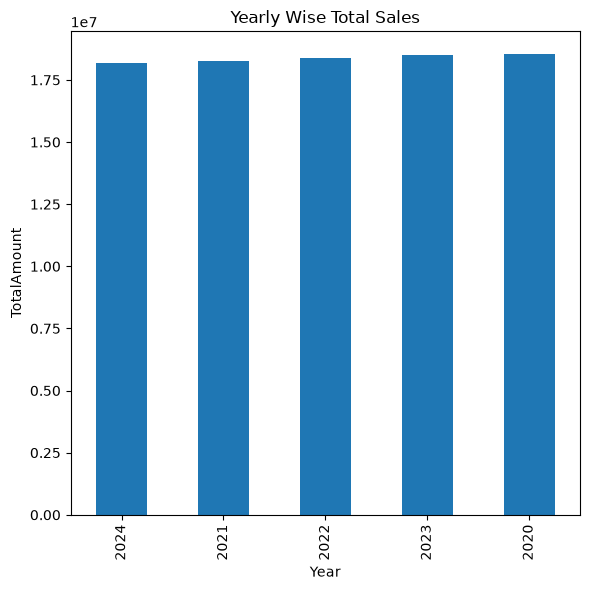

In [94]:
plt.figure(figsize=(6,6))
yearly_sales.sort_values().plot(kind="bar")
plt.title("Yearly Wise Total Sales")
plt.xlabel("Year")
plt.ylabel("TotalAmount")
plt.tight_layout()
plt.show()

MONTHLY SALES TREND

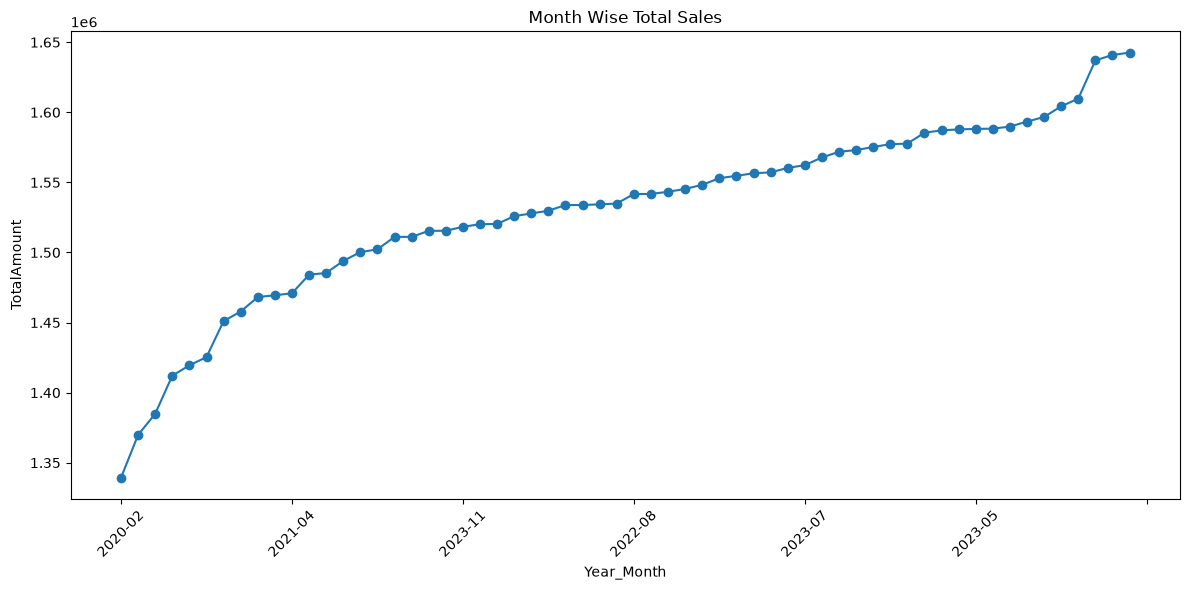

In [95]:
plt.figure(figsize=(12,6))
monthly_sales.sort_values().plot(kind="line",marker="o")
plt.title("Month Wise Total Sales")
plt.xlabel("Year_Month")
plt.ylabel("TotalAmount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

MONTHLY ORDER TREND

<function matplotlib.pyplot.show(close=None, block=None)>

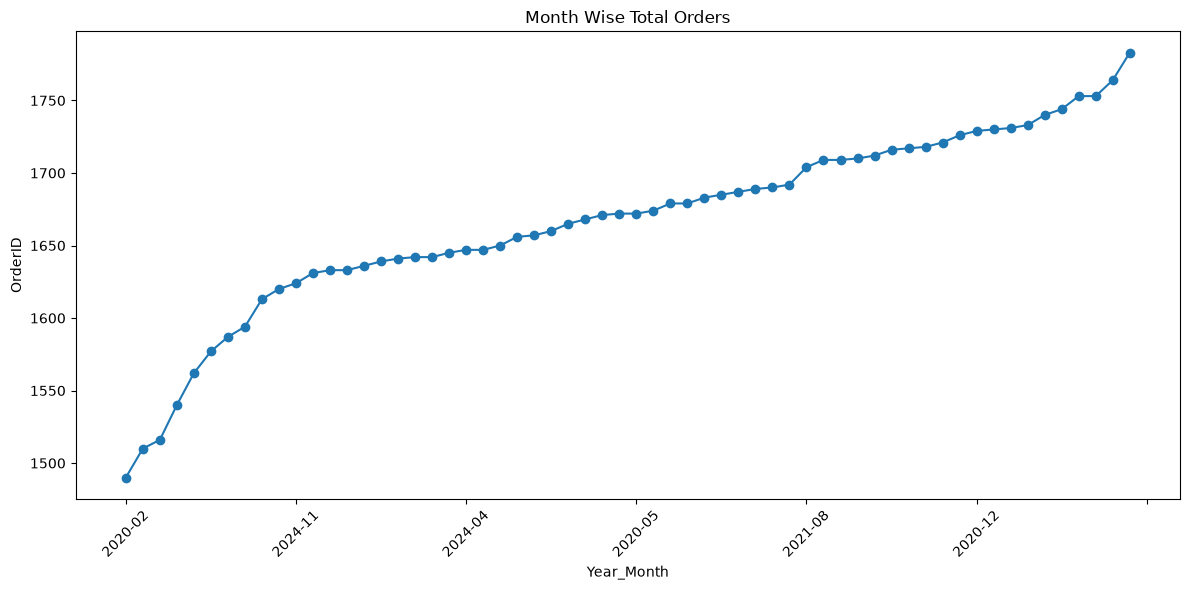

In [96]:
plt.figure(figsize=(12,6))
monthly_orders.sort_values().plot(kind="line",marker="o")
plt.title("Month Wise Total Orders")
plt.xlabel("Year_Month")
plt.ylabel("OrderID")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show

HIGHEST SALES MONTH

In [97]:
highest_sales_month = monthly_sales.idxmax()
highest_sales_value = monthly_sales.max()

print("Highest Sales Month:", highest_sales_month)
print("Sales:", highest_sales_value)

Highest Sales Month: 2024-05
Sales: 1642609.94


LOWEST SALES MONTH

In [98]:
lowest_sales_month = monthly_sales.idxmin()
lowest_sales_value = monthly_sales.min()

print("Lowest Sales Month:", lowest_sales_month)
print("Sales:", lowest_sales_value)

Lowest Sales Month: 2020-02
Sales: 1339388.21


MONTHLY GROWTH %

In [99]:
monthly_growth=monthly_sales.pct_change()*100
print(monthly_growth)

Year_Month
2020-01          NaN
2020-02   -18.183786
2020-03    18.496314
2020-04     0.076971
2020-05    -3.432066
2020-06    -2.188299
2020-07     3.513546
2020-08     5.659627
2020-09    -5.252851
2020-10    -2.526471
2020-11    -0.869166
2020-12     5.020716
2021-01    -0.152241
2021-02    -9.515120
2021-03     4.125249
2021-04    -0.894837
2021-05     6.863706
2021-06     1.371374
2021-07     0.205242
2021-08    -3.215702
2021-09    -0.673774
2021-10    -1.550177
2021-11    -6.064228
2021-12     7.092690
2022-01     5.894098
2022-02   -14.902445
2022-03    16.055805
2022-04    -4.674278
2022-05     0.814783
2022-06     0.391699
2022-07     1.479074
2022-08    -0.951792
2022-09    -5.438271
2022-10     5.246727
2022-11    -0.548249
2022-12     5.133813
2023-01    -2.275429
2023-02   -11.660814
2023-03    12.432838
2023-04     0.203935
2023-05     1.783576
2023-06    -6.471961
2023-07     5.179305
2023-08     1.480255
2023-09    -2.656573
2023-10     1.926529
2023-11    -3.479046
20

GROWTH CHART

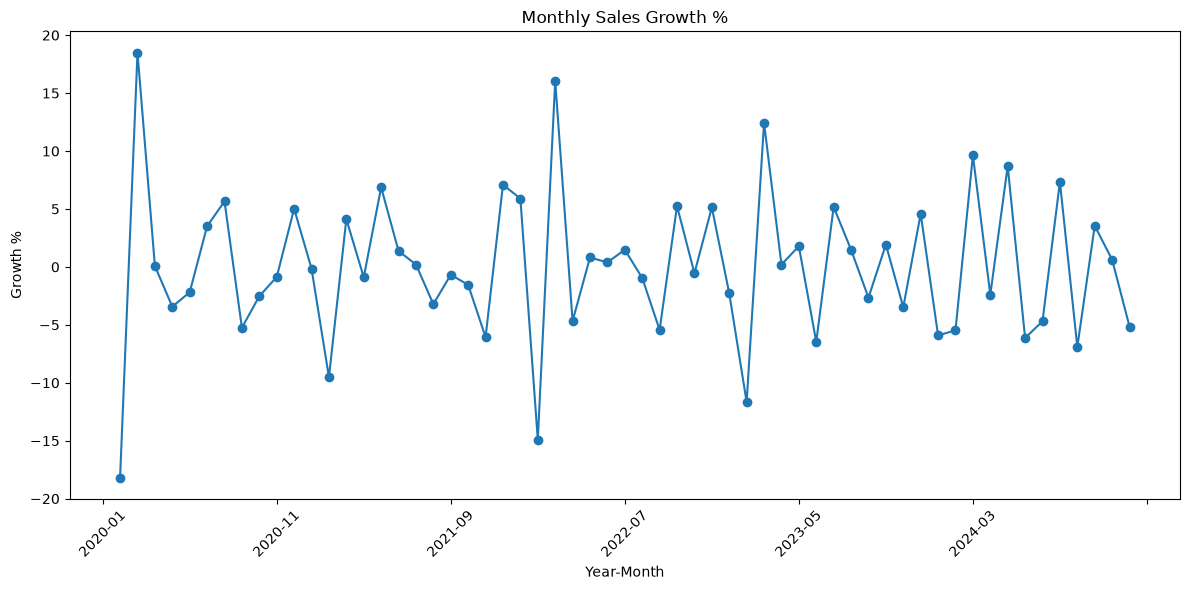

In [100]:
plt.figure(figsize=(12, 6))

monthly_growth.plot(kind="line", marker="o")

plt.title("Monthly Sales Growth %")
plt.xlabel("Year-Month")
plt.ylabel("Growth %")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

DATA VISUALIZATION

OVERALL SALES BY CATEGORY

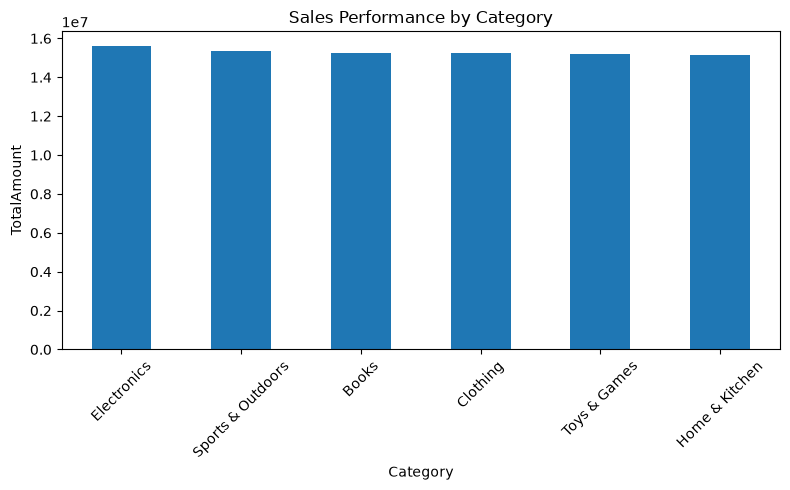

In [101]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Sales Performance by Category")
plt.xlabel("Category")
plt.ylabel("TotalAmount")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

TOP 10 PRODUCTS BY SALES

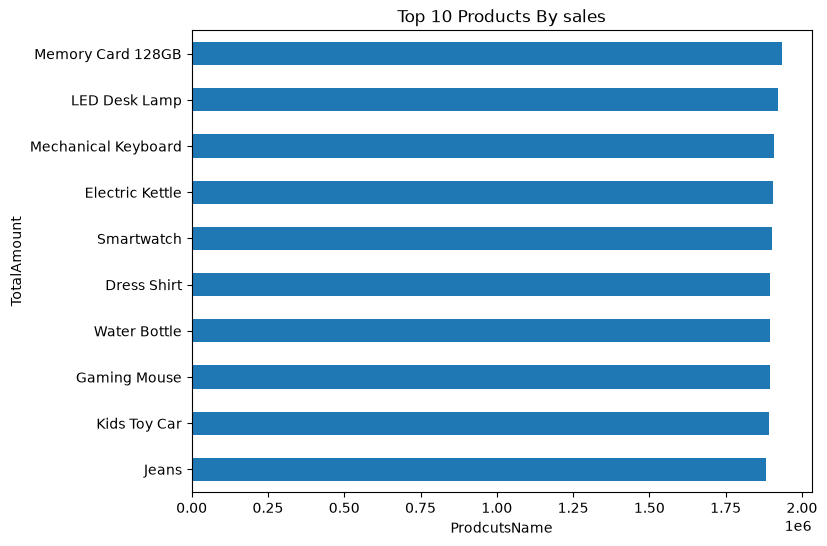

In [102]:
plt.figure(figsize=(8,6))
top10_products_by_sales.sort_values().plot(kind="barh")
plt.title("Top 10 Products By sales")
plt.xlabel("ProdcutsName")
plt.ylabel("TotalAmount")
plt.tight_layout
plt.show()

TOP 10 CUSTOMER BY SALES

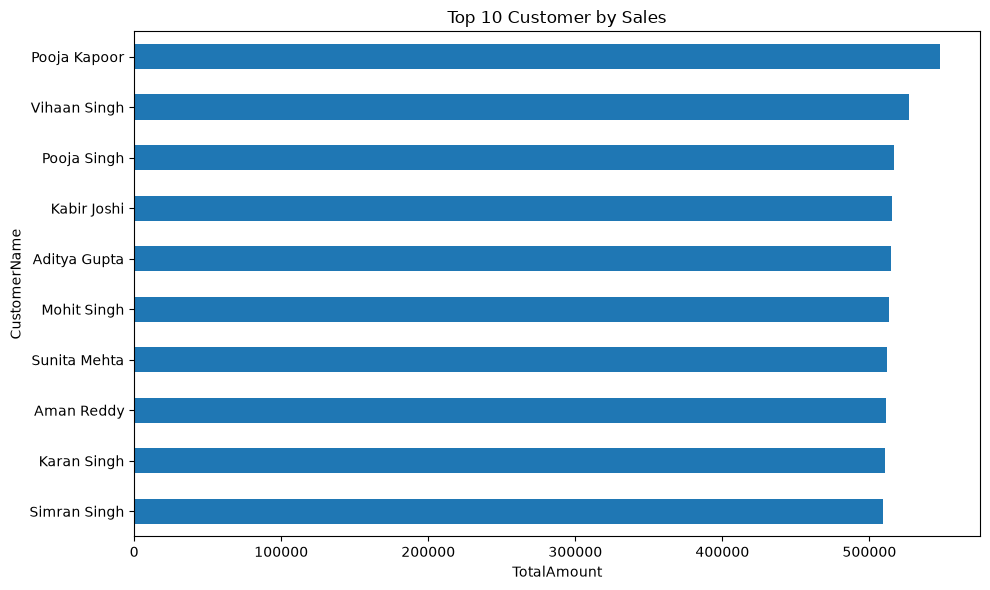

In [103]:
plt.figure(figsize=(10,6))
top10_customer_by_sales.sort_values().plot(kind="barh")
plt.title("Top 10 Customer by Sales")
plt.xlabel("TotalAmount")
plt.ylabel("CustomerName")
plt.tight_layout()
plt.show()

TOP 10 STATES BY SALES

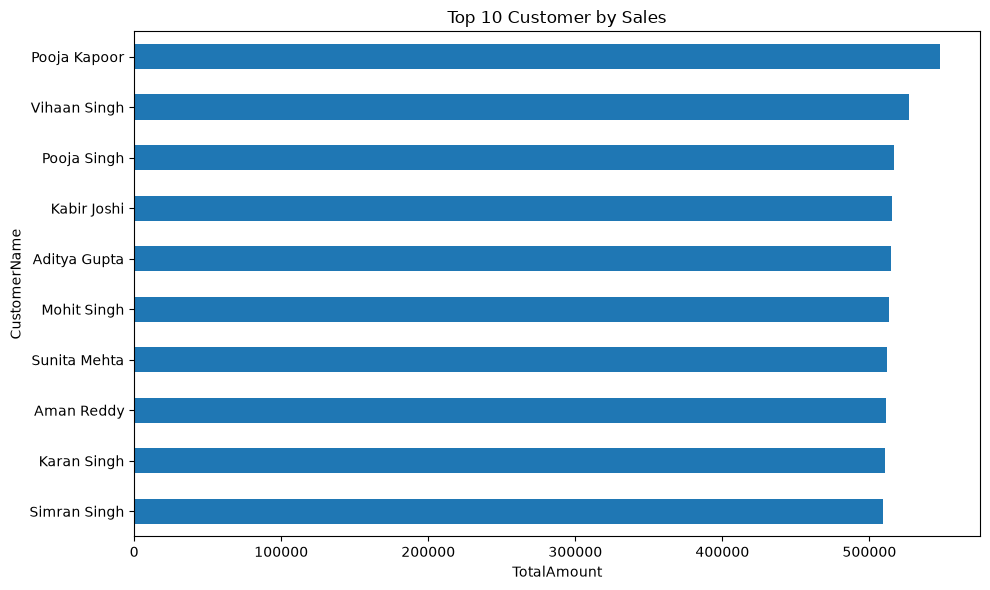

In [104]:
plt.figure(figsize=(10,6))
top10_customer_by_sales.sort_values().plot(kind="barh")
plt.title("Top 10 Customer by Sales")
plt.xlabel("TotalAmount")
plt.ylabel("CustomerName")
plt.tight_layout()
plt.show()

ORDER STATUS DISTRIBUTION

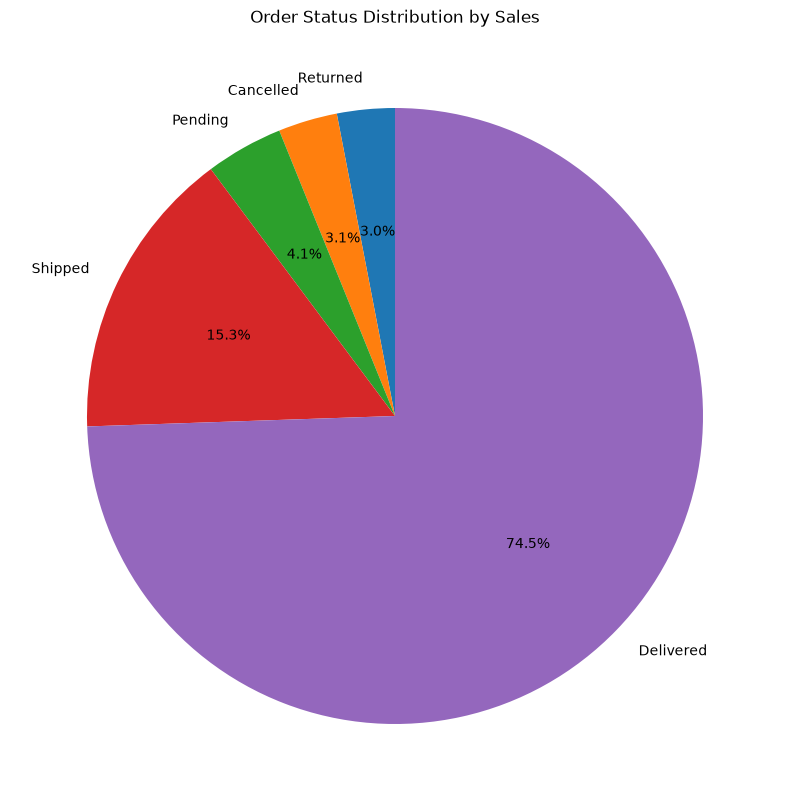

In [105]:
plt.figure(figsize=(10,10))
order_status_sales.sort_values().plot(kind="pie",autopct="%1.1f%%",startangle=90)
plt.title("Order Status Distribution by Sales")
plt.ylabel("")
plt.show()

PAYMENT METHOD DISTRIBUTION

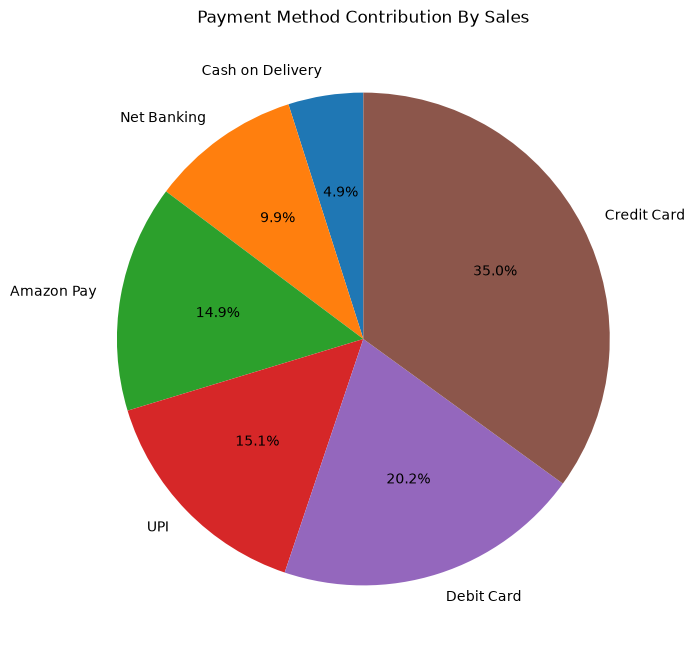

In [106]:
plt.figure(figsize=(8,8))
payment_method_sales.sort_values().plot(kind="pie",autopct="%1.1f%%",startangle=90)
plt.title("Payment Method Contribution By Sales")
plt.ylabel("")
plt.show()

MONTHLY SALES TREND

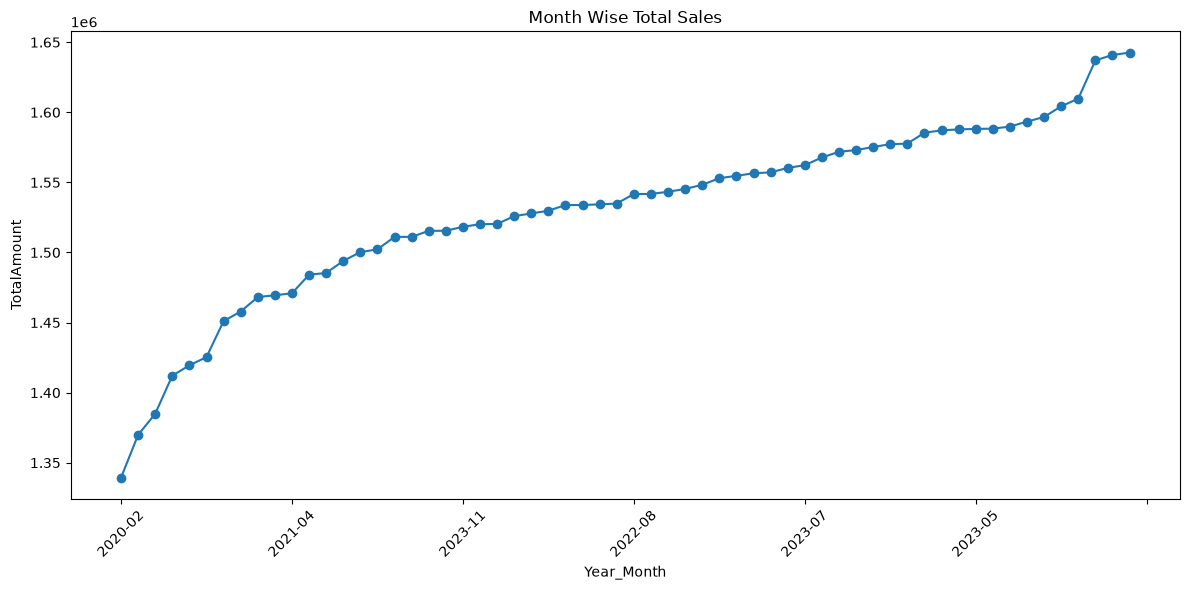

In [107]:
plt.figure(figsize=(12,6))
monthly_sales.sort_values().plot(kind="line",marker="o")
plt.title("Month Wise Total Sales")
plt.xlabel("Year_Month")
plt.ylabel("TotalAmount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

MONTHLY SALES GROWTH

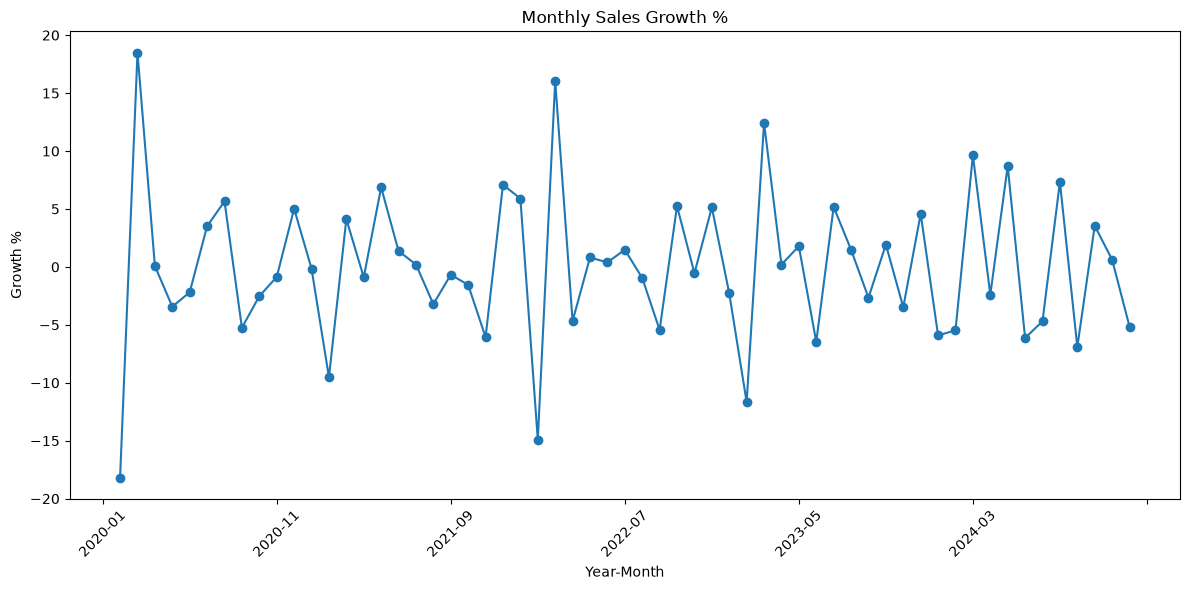

In [108]:
plt.figure(figsize=(12, 6))

monthly_growth.plot(kind="line", marker="o")

plt.title("Monthly Sales Growth %")
plt.xlabel("Year-Month")
plt.ylabel("Growth %")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

BUSINESS INSIGHTS

OVERALL SALES PERFORMANCE

In [109]:
print("Total Sales:", total_sales)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Quantity Sold:", total_quantity)
print("Average Order Value:", average_order_value)

Total Sales: 91825647.92
Total Orders: 100000
Total Customers: 200
Total Quantity Sold: 300140
Average Order Value: 918.2564792000001


BEST PERFORMING CATEGORY

In [110]:
best_category = category_sales.idxmax()
best_category_sales = category_sales.max()

print("Best Category:", best_category)
print("Sales:", best_category_sales)

Best Category: Electronics
Sales: 15584217.18


TOP PRODUCTS

In [111]:
best_products = products_sales.idxmax()
best_products_sales = products_sales.max()

print("Top Product:", best_products)
print("Sales:", best_products_sales)

Top Product: Memory Card 128GB
Sales: 1935138.4


TOP CUSTOMERS

In [112]:
top_customer = customer_sales.idxmax()
top_customer_sales = customer_sales.max()

print("Top Customer:", top_customer)
print("Sales:", top_customer_sales)

Top Customer: Pooja Kapoor
Sales: 547832.64


BEST PERFORMING STATES

In [113]:
best_state = state_sales.idxmax()
best_state_sales = state_sales.max()

print("Best State:", best_state)
print("Sales:", best_state_sales)

Best State: TX
Sales: 22862540.54


HIGHEST SALES MONTH

In [114]:
print("Highest Sales Month:", highest_sales_month)
print("Sales:", highest_sales_value)

Highest Sales Month: 2024-05
Sales: 1642609.94


MOST USED PAYMENT METHOD

In [115]:
most_used_payment = payment_method_orders.idxmax()
most_used_payment_orders = payment_method_orders.max()

print("Most Used Payment Method:", most_used_payment)
print("Orders:", most_used_payment_orders)

Most Used Payment Method: Credit Card
Orders: 35038


MOST COMMON ORDER STATUS

In [116]:
common_status = order_status_count.idxmax()
common_status_orders = order_status_count.max()

print("Most Common Order Status:", common_status)
print("Orders:", common_status_orders)

Most Common Order Status: Delivered
Orders: 74628


## 17. Business Insights

### Key Business Insights

- **Electronics** is the best-performing category based on total sales.
- **Memory Card 128GB** is the top-performing product based on sales.
- **Pooja Kapoor** is the top customer based on total sales.
- **Texas (TX)** is the best-performing state based on sales.
- **May 2024** recorded the highest monthly sales.
- **Credit Card** is the most commonly used payment method.
- **Delivered** is the most common order status.

### Business Recommendations

- Focus marketing and promotional activities on the **Electronics** category.
- Maintain sufficient inventory for high-performing products such as **Memory Card 128GB**.
- Develop customer retention strategies for high-value customers like **Pooja Kapoor**.
- Strengthen sales and marketing activities in **Texas** while exploring opportunities in lower-performing regions.
- Analyze the factors behind the strong sales performance in **May 2024** and consider similar campaigns in other periods.
- Continue supporting **Credit Card** payments while monitoring other payment preferences.
- Monitor non-delivered orders to identify opportunities to improve order fulfillment and customer experience.

## 18. Conclusion

This project analyzed Amazon sales data using Python, Pandas, NumPy, and Matplotlib.

The analysis covered:

- Overall sales and order performance
- Category-wise sales performance
- Product and brand performance
- Customer purchasing behavior
- Geographic sales performance
- Order status distribution
- Payment method preferences
- Monthly and yearly sales trends
- Sales growth analysis

### Key Findings

Electronics was the best-performing category, while Memory Card 128GB was the top-performing product based on sales.

Pooja Kapoor was the top customer by total sales, and Texas (TX) was the best-performing state.

May 2024 recorded the highest monthly sales. Credit Card was the most commonly used payment method, and Delivered was the most common order status.

Overall, the analysis provides useful insights into sales performance, customer behavior, product performance, and business trends that can support data-driven decision making.